```
RIAWELC_dataset/DB - Copy/
├── training/
│   ├── CR/ (Cracks)
│   ├── LP/ (Lack of Penetration)
│   ├── PO/ (Porosity)
│   └── ND/ (No Defect)
├── validation/
│   ├── CR/
│   ├── LP/
│   ├── PO/
│   └── ND/
└── testing/
    ├── CR/
    ├── LP/
    ├── PO/
    └── ND/
```

## Part 1: Install Required Libraries

In [77]:
# Install PyTorch and other required packages
# !pip install torch torchvision torchaudio numpy pandas matplotlib scikit-learn opencv-python 
!pip install pillow -q
print("Installation complete!")

# Install OpenCV contrib modules (ximgproc)
!pip install opencv-contrib-python
print("OpenCV contrib modules installed!")


Installation complete!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


OpenCV contrib modules installed!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 2: Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.7.1+cu118
Device: cuda
GPU: NVIDIA RTX 5000 Ada Generation


## Part 3: Set Dataset Path and Configuration

In [106]:
# UPDATE THIS PATH to your dataset location
FOLDER_PATH = r"C:\\Users\\mp29984\\Desktop\\RIAWELC\\"
DATASET_BASE_PATH = r"C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy"
DATASET_BASE_PATH = os.path.abspath(DATASET_BASE_PATH)

# Define paths
TRAINING_PATH = os.path.join(DATASET_BASE_PATH, "training")
VALIDATION_PATH = os.path.join(DATASET_BASE_PATH, "validation")
TESTING_PATH = os.path.join(DATASET_BASE_PATH, "testing")

# Define class names (after renaming)
CLASS_NAMES = ['CR', 'LP', 'PO', 'ND']  # Cracks, Lack of Penetration, Porosity, No Defect
CLASS_LABELS = {
    'CR': 'Cracks',
    'LP': 'Lack of Penetration',
    'PO': 'Porosity',
    'ND': 'No Defect'
}

# Configuration
CONFIG = {
    'image_size': 224,
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 50,
    'num_classes': 4,
    'device': device,
    'subset_size': 300,          # Number of images per class to use
    'use_clahe': True,           # Enable CLAHE preprocessing (set False to disable)
    'clahe_clip': 2.0,           # CLAHE clipLimit
    'clahe_tile': 8,              # CLAHE tileGridSize (single int -> square grid)
    'use_gaussian_blur': False,   # Enable Gaussian blur preprocessing (set False to disable)
    'gaussian_blur_kernel': 3,   # Gaussian blur kernel size (odd integer)
    'use_guided_filter': True,   # Disable guided filter preprocessing
    'guided_filter_radius': 5,   # Guided filter radius
    'guided_filter_eps': 0.01    # Guided filter epsilon
}

print(f"Training path: {TRAINING_PATH}")
print(f"Validation path: {VALIDATION_PATH}")
print(f"Testing path: {TESTING_PATH}")
print(f"\nClass names: {CLASS_NAMES}")
print(f"\nConfig: {CONFIG}")


Training path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\training
Validation path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\validation
Testing path: C:\Users\mp29984\Desktop\RIAWELC\RIAWELC\Dataset_partitioned\RIAWELC_dataset\DB - Copy\testing

Class names: ['CR', 'LP', 'PO', 'ND']

Config: {'image_size': 224, 'batch_size': 32, 'learning_rate': 0.001, 'epochs': 50, 'num_classes': 4, 'device': device(type='cuda'), 'subset_size': 300, 'use_clahe': True, 'clahe_clip': 2.0, 'clahe_tile': 8, 'use_gaussian_blur': False, 'gaussian_blur_kernel': 3, 'use_guided_filter': True, 'guided_filter_radius': 5, 'guided_filter_eps': 0.01}


## Part 4: Verify and Explore Dataset Structure

In [107]:
# Check if paths exist
print("Checking dataset structure...\n")

if os.path.exists(TRAINING_PATH):
    print(f"✓ Training path exists")
    print(f"  Contents: {sorted(os.listdir(TRAINING_PATH))}")
else:
    print(f"✗ Training path NOT found: {TRAINING_PATH}")

if os.path.exists(VALIDATION_PATH):
    print(f"\n✓ Validation path exists")
    print(f"  Contents: {sorted(os.listdir(VALIDATION_PATH))}")
else:
    print(f"\n✗ Validation path NOT found: {VALIDATION_PATH}")

if os.path.exists(TESTING_PATH):
    print(f"\n✓ Testing path exists")
    print(f"  Contents: {sorted(os.listdir(TESTING_PATH))}")
else:
    print(f"\n✗ Testing path NOT found: {TESTING_PATH}")

# Count images in each defect class
print("\n" + "="*70)
print("Image Count by Defect Class:")
print("="*70)

for class_name in CLASS_NAMES:
    train_path = os.path.join(TRAINING_PATH, class_name)
    val_path = os.path.join(VALIDATION_PATH, class_name)
    test_path = os.path.join(TESTING_PATH, class_name)
    
    train_count = len([f for f in os.listdir(train_path) if f.endswith('.png')]) if os.path.exists(train_path) else 0
    val_count = len([f for f in os.listdir(val_path) if f.endswith('.png')]) if os.path.exists(val_path) else 0
    test_count = len([f for f in os.listdir(test_path) if f.endswith('.png')]) if os.path.exists(test_path) else 0
    total = train_count + val_count + test_count
    
    print(f"{CLASS_LABELS[class_name]:25} | Train: {train_count:6} | Val: {val_count:6} | Test: {test_count:6} | Total: {total:6}")


Checking dataset structure...

✓ Training path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Validation path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

✓ Testing path exists
  Contents: ['CR', 'LP', 'ND', 'PO']

Image Count by Defect Class:
Cracks                    | Train:   4962 | Val:   1908 | Test:    765 | Total:   7635
Lack of Penetration       | Train:   4108 | Val:   1580 | Test:    632 | Total:   6320
Porosity                  | Train:   2893 | Val:   1113 | Test:    446 | Total:   4452
No Defect                 | Train:   3900 | Val:   1500 | Test:    600 | Total:   6000


Guided Filter

In [108]:
def guided_filter(I, p, r, eps):
    """Simple guided filter (He et al., 2010)"""
    I = I.astype(np.float32)
    p = p.astype(np.float32)
    mean_I = cv2.boxFilter(I, -1, (r, r))
    mean_p = cv2.boxFilter(p, -1, (r, r))
    mean_Ip = cv2.boxFilter(I * p, -1, (r, r))
    cov_Ip = mean_Ip - mean_I * mean_p
    mean_II = cv2.boxFilter(I * I, -1, (r, r))
    var_I = mean_II - mean_I * mean_I
    a = cov_Ip / (var_I + eps)
    b = mean_p - a * mean_I
    mean_a = cv2.boxFilter(a, -1, (r, r))
    mean_b = cv2.boxFilter(b, -1, (r, r))
    q = mean_a * I + mean_b
    return q

## Part 5: Create Custom Dataset Class

In [109]:
class RIAWELCDataset(Dataset):
    """
    Custom PyTorch Dataset for RIAWELC weld defect images
    """
    def __init__(self, root_path, class_names, transform=None, subset_size=None):
        """
        Args:
            root_path: Path to training, validation or testing folder
            class_names: List of class folder names
            transform: Image transformations to apply
            subset_size: Number of images per class to use (for sampling)
        """
        self.root_path = root_path
        self.class_names = class_names
        self.transform = transform
        self.subset_size = subset_size
        self.images = []
        self.labels = []
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
        
        # Load all images
        self._load_images()
    
    def _load_images(self):
        """Load all image paths and labels with optional subset sampling"""
        for class_name in self.class_names:
            class_path = os.path.join(self.root_path, class_name)
            if os.path.exists(class_path):
                image_files = [f for f in os.listdir(class_path) if f.endswith('.png')]
                
                # If subset_size is specified, randomly sample images
                if self.subset_size and len(image_files) > self.subset_size:
                    image_files = np.random.choice(image_files, self.subset_size, replace=False)
                
                for img_file in image_files:
                    self.images.append(os.path.join(class_path, img_file))
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image (grayscale)
        img_path = self.images[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            raise ValueError(f"Failed to load image: {img_path}")
        
        # Resize if needed
        if image.shape != (CONFIG['image_size'], CONFIG['image_size']):
            image = cv2.resize(image, (CONFIG['image_size'], CONFIG['image_size']))

        # Noise reduction gaussian blur
        if CONFIG.get('use_gaussian_blur', True):
            kernel = int(CONFIG.get('gaussian_blur_kernel', 3))
            image = cv2.GaussianBlur(image, (kernel, kernel), 0)

        # Guided filter if enabled
        if CONFIG.get('use_guided_filter', True):
            radius = int(CONFIG.get('guided_filter_radius', 5))
            eps = float(CONFIG.get('guided_filter_eps', 0.01))
            image = guided_filter(I=image, p=image, r=radius, eps=eps)
            # Convert back to uint8
            image = np.uint8(np.clip(image, 0, 255))
        
        # Apply CLAHE if enabled (on grayscale image)
        if CONFIG.get('use_clahe', False):
            clip = float(CONFIG.get('clahe_clip', 2.0))
            tile = int(CONFIG.get('clahe_tile', 8))
            clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
            image = clahe.apply(image)
        
        # Convert to 3-channel (RGB) for PyTorch compatibility
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        # Apply transformations
        if self.transform:
            image = self.transform(Image.fromarray(image))
        else:
            image = transforms.ToTensor()(Image.fromarray(image))
        
        label = self.labels[idx]
        return image, label

print("RIAWELCDataset class created successfully!")


RIAWELCDataset class created successfully!


## Part 6: Create Data Transformations

In [110]:
# Define data transformations
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Data transformations created!")


Data transformations created!


## Part 7: Load Datasets and Create DataLoaders

In [111]:
# Load datasets with subset sampling
print("Loading datasets...")

# Load training dataset
train_dataset = RIAWELCDataset(
    TRAINING_PATH, 
    CLASS_NAMES, 
    transform=train_transform,
    subset_size=CONFIG['subset_size']
)

# Load validation dataset
val_dataset = RIAWELCDataset(
    VALIDATION_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size']
)

# Load testing dataset
test_dataset = RIAWELCDataset(
    TESTING_PATH, 
    CLASS_NAMES, 
    transform=val_test_transform,
    subset_size=CONFIG['subset_size']
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Testing dataset size: {len(test_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


Loading datasets...
Training dataset size: 1200
Validation dataset size: 1200
Testing dataset size: 1200

DataLoaders created:
  Train batches: 38
  Validation batches: 38
  Test batches: 38


## Part 8: Visualize Sample Images

In [ ]:
# Display sample images from training set
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Sample Images from Each Weld Defect Class (Training Set)', 
             fontsize=16, fontweight='bold')

# Get one image per class
class_samples = {}
for img, label in train_dataset:
    if label not in class_samples:
        class_samples[label] = img
    if len(class_samples) == CONFIG['num_classes']:
        break

# Display
for class_idx, ax in enumerate(axes.flat):
    if class_idx in class_samples:
        img = class_samples[class_idx]
        # Denormalize for display
        img_display = (img * 0.5 + 0.5).numpy()
        img_display = np.transpose(img_display, (1, 2, 0))
        img_display = np.mean(img_display, axis=2)  # Convert to grayscale for display
        
        class_name = CLASS_NAMES[class_idx]
        ax.imshow(img_display, cmap='gray')
        ax.set_title(f"{class_name}\n{CLASS_LABELS[class_name]}", fontweight='bold', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed!")


Applied guided filter on class CR
Applied guided filter on class LP
Applied guided filter on class PO
Applied guided filter on class ND


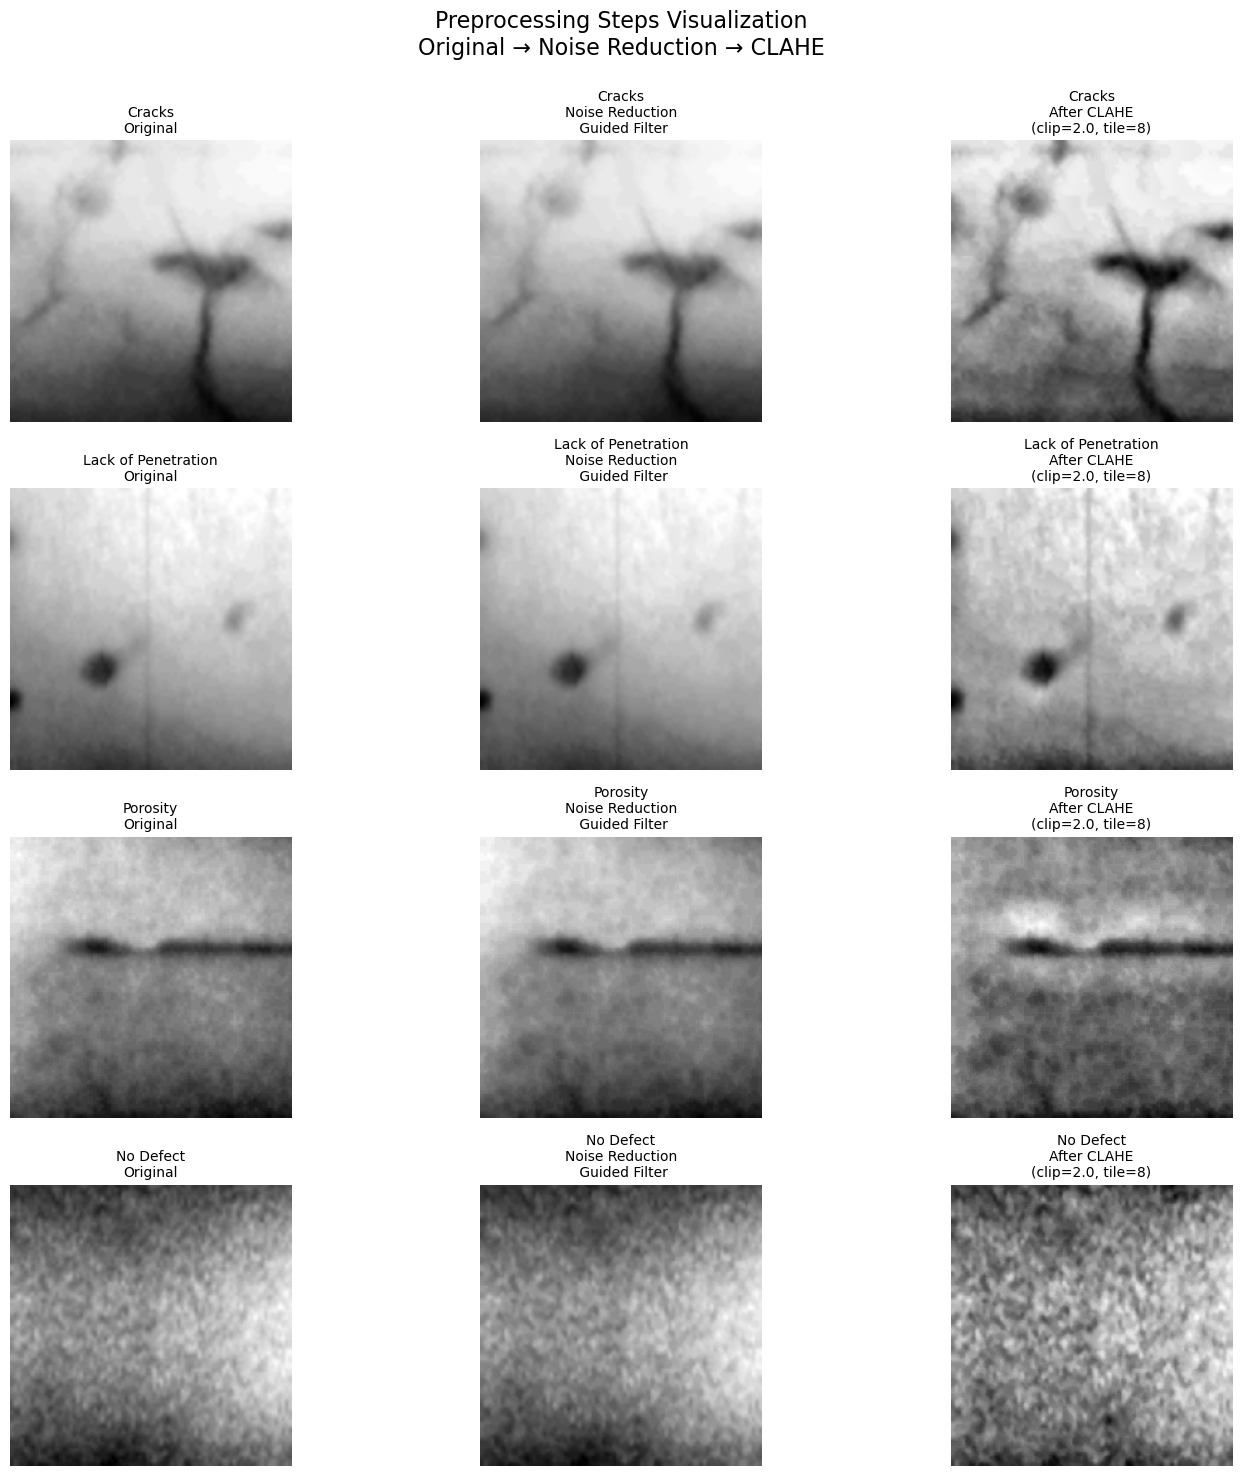

Displayed preprocessing steps for classes: ['CR', 'LP', 'PO', 'ND']


In [114]:
# Visualize original vs noise reduction vs CLAHE for one sample per class
import math

n_classes = len(CLASS_NAMES)
fig, axes = plt.subplots(n_classes, 3, figsize=(15, 4 * n_classes))
fig.suptitle('Preprocessing Steps Visualization\nOriginal → Noise Reduction → CLAHE', 
             fontsize=16, y=0.95)

# Define preprocessing parameters from CONFIG
clip = float(CONFIG.get('clahe_clip', 2.0))
tile = int(CONFIG.get('clahe_tile', 8))
kernel = int(CONFIG.get('gaussian_blur_kernel', 3))
radius = 2
eps = float(CONFIG.get('guided_filter_eps', 0.01))

clahe_op = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))

for i, class_name in enumerate(CLASS_NAMES):
    # Find a sample image in training folder
    class_dir = os.path.join(TRAINING_PATH, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith('.png')] if os.path.exists(class_dir) else []
    if not files:
        for j in range(3):
            axes[i, j].text(0.5, 0.5, 'No image', ha='center')
            axes[i, j].axis('off')
        continue

    # Load image
    img_path = os.path.join(class_dir, files[0])
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        for j in range(3):
            axes[i, j].text(0.5, 0.5, 'Load failed', ha='center')
            axes[i, j].axis('off')
        continue

    # Resize
    img_resized = cv2.resize(img_gray, (CONFIG['image_size'], CONFIG['image_size']))
    
    # Apply noise reduction (Gaussian blur)
    # img_blurred = cv2.GaussianBlur(img_resized, (kernel, kernel), 0)

    # Apply guided filter if enabled
    if CONFIG.get('use_guided_filter', True):
        img_blurred = guided_filter(I=img_resized, p=img_resized, r=radius, eps=eps)
        img_blurred = np.uint8(np.clip(img_blurred, 0, 255))
        print(f"Applied guided filter on class {class_name}")
    else:
        img_blurred = cv2.GaussianBlur(img_resized, (kernel, kernel), 0)
    
    # Apply CLAHE on blurred image
    img_clahe = clahe_op.apply(img_blurred)

    # Display original
    axes[i, 0].imshow(img_resized, cmap='gray')
    axes[i, 0].set_title(f"{CLASS_LABELS[class_name]}\nOriginal", fontsize=10)
    axes[i, 0].axis('off')

    # Display noise reduced
    axes[i, 1].imshow(img_blurred, cmap='gray')
    axes[i, 1].set_title(f"{CLASS_LABELS[class_name]}\nNoise Reduction\n {"Gaussian Blur" if CONFIG.get('use_gaussian_blur', False) else 'Guided Filter'}", fontsize=10)
    axes[i, 1].axis('off')

    # Display CLAHE
    axes[i, 2].imshow(img_clahe, cmap='gray')
    axes[i, 2].set_title(f"{CLASS_LABELS[class_name]}\nAfter CLAHE\n(clip={clip}, tile={tile})", fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('Displayed preprocessing steps for classes:', CLASS_NAMES)

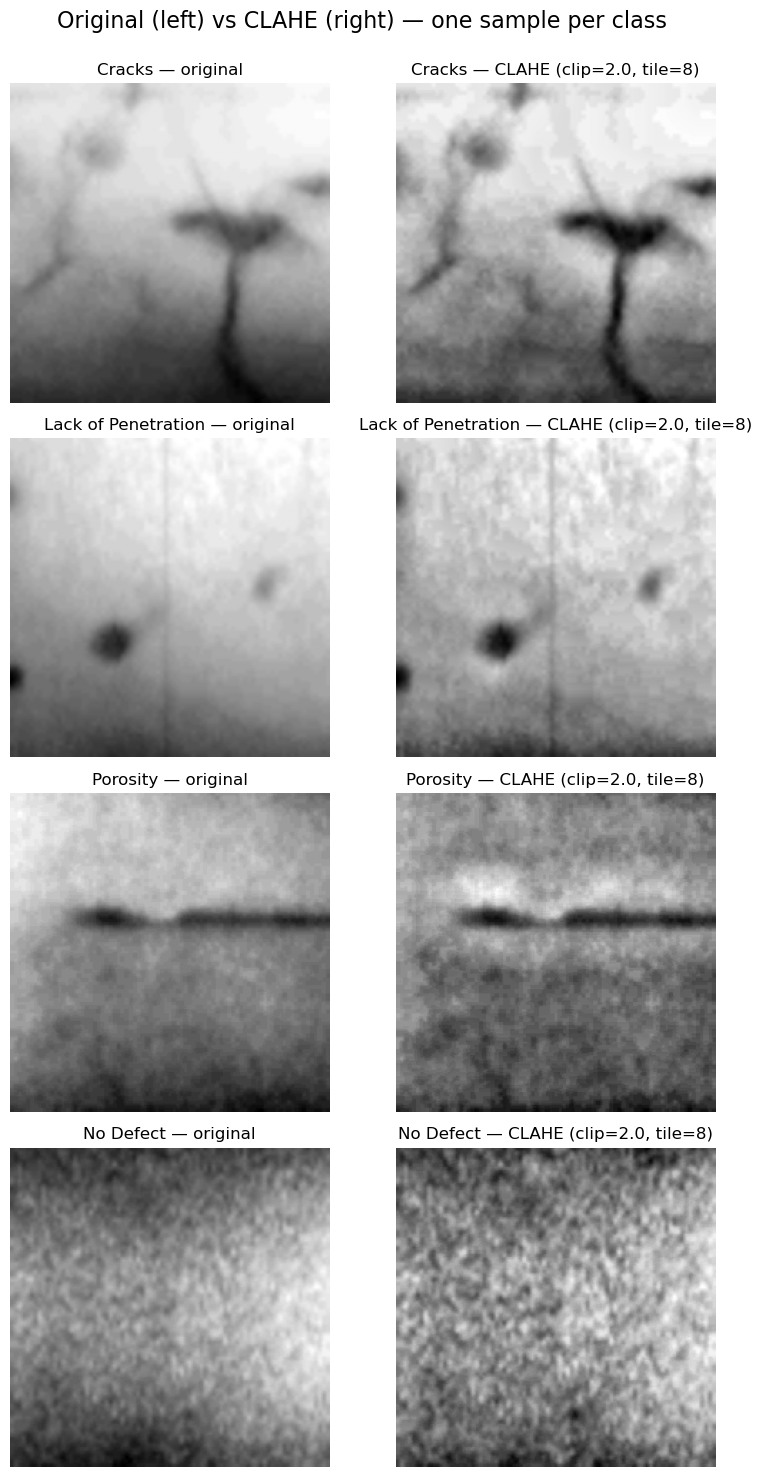

Displayed original vs CLAHE for classes: ['CR', 'LP', 'PO', 'ND']


In [ ]:
# # Visualize original vs CLAHE for one sample per class
# import math

# n_classes = len(CLASS_NAMES)
# fig, axes = plt.subplots(n_classes, 2, figsize=(8, 4 * n_classes))
# fig.suptitle('Original (left) vs CLAHE (right) — one sample per class', fontsize=16, y=0.95)

# clip = float(CONFIG.get('clahe_clip', 2.0))
# tile = int(CONFIG.get('clahe_tile', 8))
# clahe_op = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))

# for i, class_name in enumerate(CLASS_NAMES):
#     # find a sample image in training folder
#     class_dir = os.path.join(TRAINING_PATH, class_name)
#     files = [f for f in os.listdir(class_dir) if f.lower().endswith('.png')] if os.path.exists(class_dir) else []
#     if not files:
#         axes[i, 0].text(0.5, 0.5, 'No image', ha='center')
#         axes[i, 1].text(0.5, 0.5, 'No image', ha='center')
#         axes[i, 0].axis('off'); axes[i, 1].axis('off')
#         continue

#     img_path = os.path.join(class_dir, files[0])
#     img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#     if img_gray is None:
#         axes[i, 0].text(0.5, 0.5, 'Load failed', ha='center')
#         axes[i, 1].text(0.5, 0.5, 'Load failed', ha='center')
#         axes[i, 0].axis('off'); axes[i, 1].axis('off')
#         continue

#     img_resized = cv2.resize(img_gray, (CONFIG['image_size'], CONFIG['image_size']))
#     img_clahe = clahe_op.apply(img_resized)

#     # display original
#     axes[i, 0].imshow(img_resized, cmap='gray')
#     axes[i, 0].set_title(f"{CLASS_LABELS[class_name]} — original")
#     axes[i, 0].axis('off')

#     # display CLAHE
#     axes[i, 1].imshow(img_clahe, cmap='gray')
#     axes[i, 1].set_title(f"{CLASS_LABELS[class_name]} — CLAHE (clip={clip}, tile={tile})")
#     axes[i, 1].axis('off')

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()

# print('Displayed original vs CLAHE for classes:', CLASS_NAMES)


## Part 9: Visualize Class Distribution

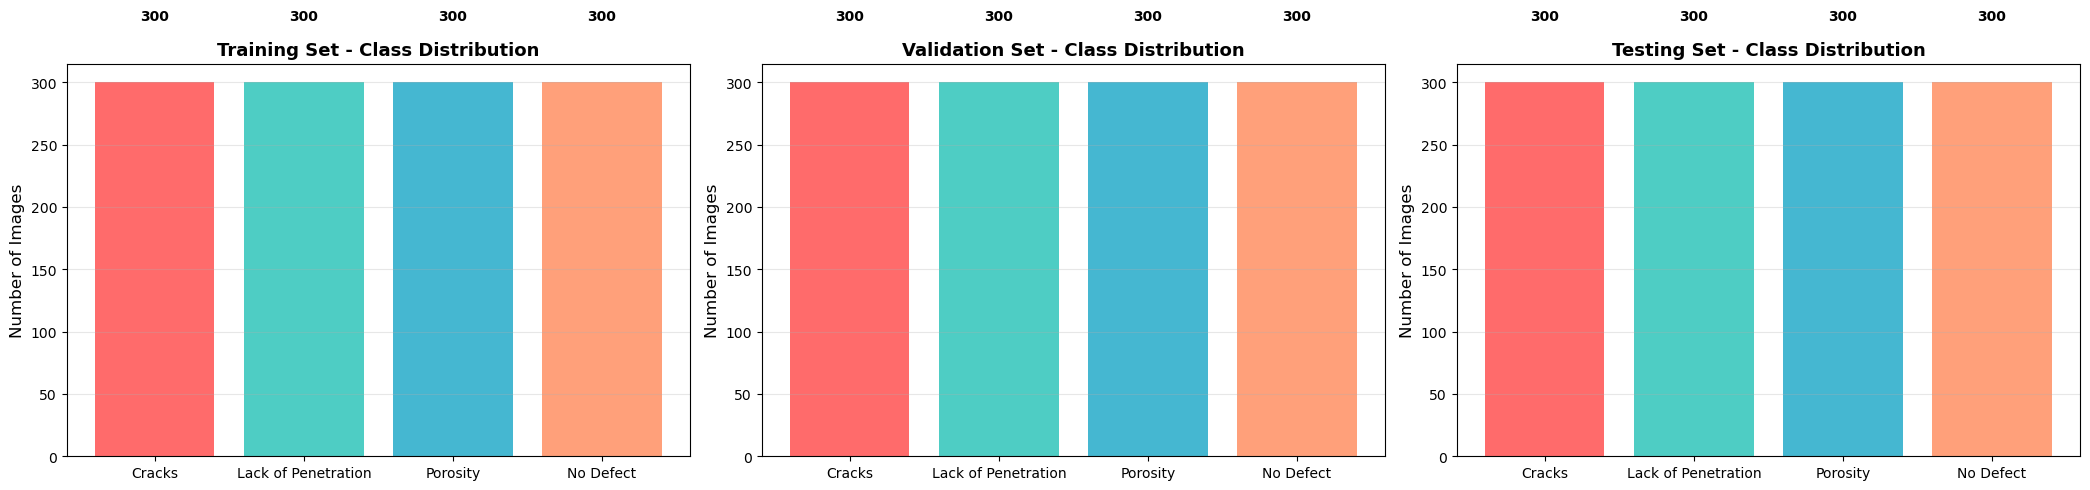


Class Distribution Summary:
Training: {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}
Validation: {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}
Testing:  {'Cracks': 300, 'Lack of Penetration': 300, 'Porosity': 300, 'No Defect': 300}


In [16]:
# Calculate class distribution
train_class_counts = [0] * CONFIG['num_classes']
val_class_counts = [0] * CONFIG['num_classes']
test_class_counts = [0] * CONFIG['num_classes']

for _, label in train_dataset:
    train_class_counts[label] += 1

for _, label in val_dataset:
    val_class_counts[label] += 1

for _, label in test_dataset:
    test_class_counts[label] += 1

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
class_labels_display = [CLASS_LABELS[name] for name in CLASS_NAMES]

# Training distribution
axes[0].bar(class_labels_display, train_class_counts, color=colors)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Training Set - Class Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, count in enumerate(train_class_counts):
    axes[0].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Validation distribution
axes[1].bar(class_labels_display, val_class_counts, color=colors)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].set_title('Validation Set - Class Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, count in enumerate(val_class_counts):
    axes[1].text(i, count + 50, str(count), ha='center', fontweight='bold')

# Testing distribution
axes[2].bar(class_labels_display, test_class_counts, color=colors)
axes[2].set_ylabel('Number of Images', fontsize=12)
axes[2].set_title('Testing Set - Class Distribution', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for i, count in enumerate(test_class_counts):
    axes[2].text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass Distribution Summary:")
print(f"Training: {dict(zip(class_labels_display, train_class_counts))}")
print(f"Validation: {dict(zip(class_labels_display, val_class_counts))}")
print(f"Testing:  {dict(zip(class_labels_display, test_class_counts))}")


## Part 10: Define CNN Model

In [18]:
from torchvision import models

# Choose backbone: 'custom', 'resnet50', 'efficientnet_b0'
BACKBONE = 'efficientnet_b0'  # change as needed
USE_PRETRAINED = True
FREEZE_BACKBONE = False  # set False to fine-tune entire model

if BACKBONE == 'custom':
    class WeldDefectCNN(nn.Module):
        """
        Convolutional Neural Network for weld defect classification
        """
        def __init__(self, num_classes=4):
            super(WeldDefectCNN, self).__init__()
            
            # Block 1
            self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm2d(32)
            self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm2d(32)
            self.pool1 = nn.MaxPool2d(2, 2)
            self.dropout1 = nn.Dropout(0.25)
            
            # Block 2
            self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
            self.bn3 = nn.BatchNorm2d(64)
            self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
            self.bn4 = nn.BatchNorm2d(64)
            self.pool2 = nn.MaxPool2d(2, 2)
            self.dropout2 = nn.Dropout(0.25)
            
            # Block 3
            self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
            self.bn5 = nn.BatchNorm2d(128)
            self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
            self.bn6 = nn.BatchNorm2d(128)
            self.pool3 = nn.MaxPool2d(2, 2)
            self.dropout3 = nn.Dropout(0.25)
            
            # Block 4
            self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
            self.bn7 = nn.BatchNorm2d(256)
            self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
            self.bn8 = nn.BatchNorm2d(256)
            self.pool4 = nn.MaxPool2d(2, 2)
            self.dropout4 = nn.Dropout(0.25)
            
            # Flatten and Dense layers
            self.fc1 = nn.Linear(256 * 14 * 14, 512)
            self.dropout5 = nn.Dropout(0.5)
            self.fc2 = nn.Linear(512, 256)
            self.dropout6 = nn.Dropout(0.5)
            self.fc3 = nn.Linear(256, num_classes)
            
            self.relu = nn.ReLU()
        
        def forward(self, x):
            # Block 1
            x = self.relu(self.bn1(self.conv1(x)))
            x = self.relu(self.bn2(self.conv2(x)))
            x = self.pool1(x)
            x = self.dropout1(x)
            
            # Block 2
            x = self.relu(self.bn3(self.conv3(x)))
            x = self.relu(self.bn4(self.conv4(x)))
            x = self.pool2(x)
            x = self.dropout2(x)
            
            # Block 3
            x = self.relu(self.bn5(self.conv5(x)))
            x = self.relu(self.bn6(self.conv6(x)))
            x = self.pool3(x)
            x = self.dropout3(x)
            
            # Block 4
            x = self.relu(self.bn7(self.conv7(x)))
            x = self.relu(self.bn8(self.conv8(x)))
            x = self.pool4(x)
            x = self.dropout4(x)
            
            # Flatten
            x = x.view(x.size(0), -1)
            
            # Dense layers
            x = self.relu(self.fc1(x))
            x = self.dropout5(x)
            x = self.relu(self.fc2(x))
            x = self.dropout6(x)
            x = self.fc3(x)
            
            return x

    model = WeldDefectCNN(num_classes=CONFIG['num_classes']).to(device)

elif BACKBONE == 'resnet50':
    # Load ResNet50 and replace final fc
    backbone = models.resnet50(pretrained=USE_PRETRAINED)
    in_features = backbone.fc.in_features
    backbone.fc = nn.Linear(in_features, CONFIG['num_classes'])
    model = backbone.to(device)
    if FREEZE_BACKBONE:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False

elif BACKBONE == 'efficientnet_b0':
    # Load EfficientNet-B0 and replace classifier
    backbone = models.efficientnet_b0(pretrained=USE_PRETRAINED)
    # EfficientNet classifier is a Sequential: (Dropout, Linear)
    in_features = backbone.classifier[1].in_features
    backbone.classifier[1] = nn.Linear(in_features, CONFIG['num_classes'])
    model = backbone.to(device)
    if FREEZE_BACKBONE:
        for name, param in model.named_parameters():
            if 'classifier' not in name:
                param.requires_grad = False

else:
    raise ValueError(f'Unsupported BACKBONE: {BACKBONE}')

def count_trainable_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print('Model created!')
print(f'Backbone: {BACKBONE}, pretrained={USE_PRETRAINED}, freeze_backbone={FREEZE_BACKBONE}')
print(f'Trainable parameters: {count_trainable_params(model):,}')
print('\nModel Summary:')
print(model)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\mp29984/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:00<00:00, 80.9MB/s]



Model created!
Backbone: efficientnet_b0, pretrained=True, freeze_backbone=False
Trainable parameters: 4,012,672

Model Summary:
EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
  

## Part 11: Define Loss Function and Optimizer

In [19]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Only include parameters that require gradients (useful if backbone frozen)
trainable_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = optim.Adam(trainable_params, lr=CONFIG['learning_rate'])

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print('Loss function: CrossEntropyLoss')
print(f'Optimizer: Adam (lr={CONFIG['learning_rate']})')
print('Scheduler: ReduceLROnPlateau')


Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## Part 12: Define Training Functions

In [20]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        if (batch_idx + 1) % 10 == 0:
            print(f'  Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """
    Validate model
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training functions defined!")


Training functions defined!


## Part 13: Train the Model

In [21]:
import time
id  = time.time()
# format like date time
id = time.strftime("%Y-%m-%d---%H-%M-%S", time.localtime(id))
print(f"Unique run ID: {id}")


Unique run ID: 2025-10-30---18-17-00


In [22]:
# Training loop
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
patience = 10
patience_counter = 0
best_model_path = f"{FOLDER_PATH}best_model_{id}.pth"
print(f"Training for {CONFIG['epochs']} epochs...\n")

for epoch in range(CONFIG['epochs']):
    print(f"Epoch [{epoch+1}/{CONFIG['epochs']}]")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%\n')
    
    # Learning rate scheduler
    scheduler.step(val_acc)
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # Save best model
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("\nTraining completed!")


Training for 50 epochs...

Epoch [1/50]
  Batch [10/38], Loss: 0.4705
  Batch [10/38], Loss: 0.4705
  Batch [20/38], Loss: 0.6481
  Batch [20/38], Loss: 0.6481
  Batch [30/38], Loss: 0.4547
  Batch [30/38], Loss: 0.4547
  Train Loss: 0.6221, Train Acc: 77.00%
  Val Loss: 0.3786, Val Acc: 87.92%

Epoch [2/50]
  Train Loss: 0.6221, Train Acc: 77.00%
  Val Loss: 0.3786, Val Acc: 87.92%

Epoch [2/50]
  Batch [10/38], Loss: 0.2251
  Batch [10/38], Loss: 0.2251
  Batch [20/38], Loss: 0.3570
  Batch [20/38], Loss: 0.3570
  Batch [30/38], Loss: 0.2759
  Batch [30/38], Loss: 0.2759
  Train Loss: 0.3583, Train Acc: 87.92%
  Val Loss: 0.1229, Val Acc: 95.83%

Epoch [3/50]
  Train Loss: 0.3583, Train Acc: 87.92%
  Val Loss: 0.1229, Val Acc: 95.83%

Epoch [3/50]
  Batch [10/38], Loss: 0.2041
  Batch [10/38], Loss: 0.2041
  Batch [20/38], Loss: 0.5621
  Batch [20/38], Loss: 0.5621
  Batch [30/38], Loss: 0.7668
  Batch [30/38], Loss: 0.7668
  Train Loss: 0.2765, Train Acc: 91.42%
  Val Loss: 0.2540, 

## Part 14: Plot Training History

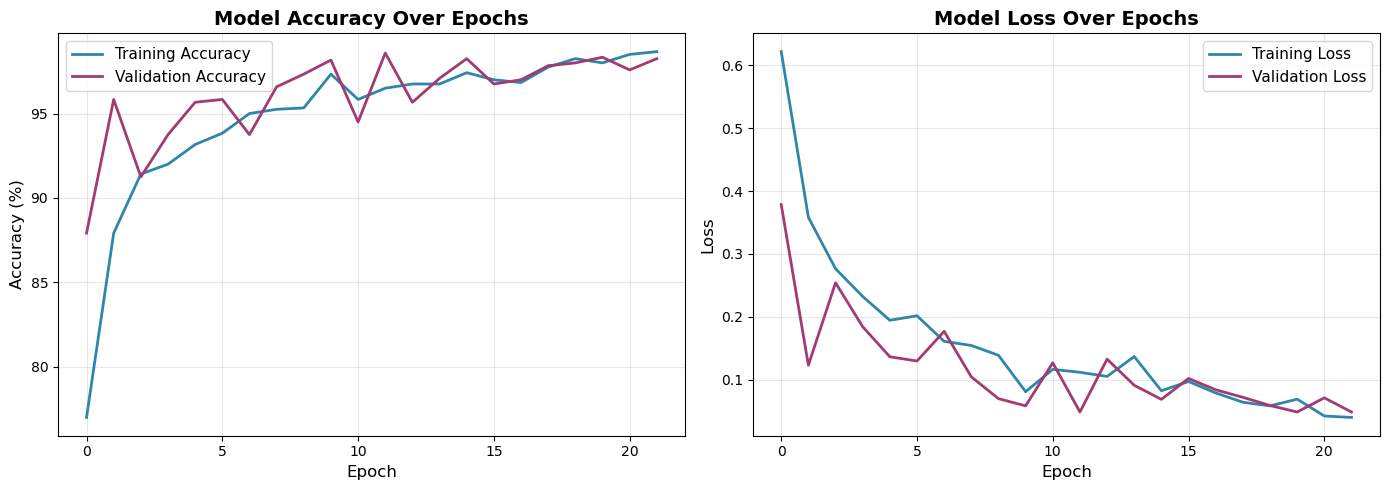

Best epoch: 12
Best validation accuracy: 98.58%


In [23]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history['train_acc'], label='Training Accuracy', linewidth=2, color='#2E86AB')
ax1.plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='#A23B72')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(history['train_loss'], label='Training Loss', linewidth=2, color='#2E86AB')
ax2.plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#A23B72')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print best metrics
best_epoch = np.argmax(history['val_acc'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Best validation accuracy: {history['val_acc'][best_epoch]:.2f}%")


In [45]:
print("="*60)
print("Training results")
print("="*60)

model.eval()
train_correct_count = 0
train_total = 0
y_true_train = []
y_pred_train = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        train_total += labels.size(0)
        train_correct_count += (predicted == labels).sum().item()

        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(predicted.cpu().numpy())

train_accuracy = 100 * train_correct_count / train_total if train_total > 0 else 0

print("\n" + "="*60)
print("TRAIN SET PERFORMANCE")
print("="*60)
print(f"Train Accuracy: {train_accuracy:.2f}%")
print(f"Correct: {train_correct_count}/{train_total}")


# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT ON TRAIN SET")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
if len(y_true_train) == 0:
    print("No training predictions collected.")
else:
    print(classification_report(y_true_train, y_pred_train, target_names=target_names))


Training results

TRAIN SET PERFORMANCE
Train Accuracy: 99.00%
Correct: 1188/1200

CLASSIFICATION REPORT ON TRAIN SET
                     precision    recall  f1-score   support

             Cracks       0.99      0.97      0.98       300
Lack of Penetration       1.00      1.00      1.00       300
           Porosity       0.97      0.99      0.98       300
          No Defect       1.00      1.00      1.00       300

           accuracy                           0.99      1200
          macro avg       0.99      0.99      0.99      1200
       weighted avg       0.99      0.99      0.99      1200


TRAIN SET PERFORMANCE
Train Accuracy: 99.00%
Correct: 1188/1200

CLASSIFICATION REPORT ON TRAIN SET
                     precision    recall  f1-score   support

             Cracks       0.99      0.97      0.98       300
Lack of Penetration       1.00      1.00      1.00       300
           Porosity       0.97      0.99      0.98       300
          No Defect       1.00      1.00     

In [46]:
print("="*60)
print("Validation results")
print("="*60)

model.eval()
validation_correct_count = 0
validation_total = 0
y_true_validation = []
y_pred_validation = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        validation_total += labels.size(0)
        validation_correct_count += (predicted == labels).sum().item()

        y_true_validation.extend(labels.cpu().numpy())
        y_pred_validation.extend(predicted.cpu().numpy())

validation_accuracy = 100 * validation_correct_count / validation_total if validation_total > 0 else 0

print("\n" + "="*60)
print("VALIDATION SET PERFORMANCE")
print("="*60)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")
print(f"Correct: {validation_correct_count}/{validation_total}")


# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT ON VALIDATION SET")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
if len(y_true_validation) == 0:
    print("No validation predictions collected.")
else:
    print(classification_report(y_true_validation, y_pred_validation, target_names=target_names))


Validation results

VALIDATION SET PERFORMANCE
Validation Accuracy: 98.58%
Correct: 1183/1200

CLASSIFICATION REPORT ON VALIDATION SET
                     precision    recall  f1-score   support

             Cracks       0.99      0.98      0.98       300
Lack of Penetration       0.99      0.98      0.98       300
           Porosity       0.97      0.98      0.98       300
          No Defect       1.00      1.00      1.00       300

           accuracy                           0.99      1200
          macro avg       0.99      0.99      0.99      1200
       weighted avg       0.99      0.99      0.99      1200


VALIDATION SET PERFORMANCE
Validation Accuracy: 98.58%
Correct: 1183/1200

CLASSIFICATION REPORT ON VALIDATION SET
                     precision    recall  f1-score   support

             Cracks       0.99      0.98      0.98       300
Lack of Penetration       0.99      0.98      0.98       300
           Porosity       0.97      0.98      0.98       300
          No 

## Part 15: Load Best Model and Evaluate on Test Set

In [48]:
# Load best model
model.load_state_dict(torch.load(best_model_path))
print("Best model loaded!")

# Evaluate on test set
model.eval()
test_correct = 0
test_total = 0
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_accuracy = 100 * test_correct / test_total

print("\n" + "="*60)
print("TEST SET PERFORMANCE")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {test_correct}/{test_total}")

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = [CLASS_LABELS[name] for name in CLASS_NAMES]
print(classification_report(y_true, y_pred, target_names=target_names))


Best model loaded!

TEST SET PERFORMANCE
Test Accuracy: 97.08%
Correct: 1165/1200

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

             Cracks       0.98      0.93      0.96       300
Lack of Penetration       0.99      0.97      0.98       300
           Porosity       0.93      0.98      0.95       300
          No Defect       0.99      1.00      1.00       300

           accuracy                           0.97      1200
          macro avg       0.97      0.97      0.97      1200
       weighted avg       0.97      0.97      0.97      1200


TEST SET PERFORMANCE
Test Accuracy: 97.08%
Correct: 1165/1200

CLASSIFICATION REPORT
                     precision    recall  f1-score   support

             Cracks       0.98      0.93      0.96       300
Lack of Penetration       0.99      0.97      0.98       300
           Porosity       0.93      0.98      0.95       300
          No Defect       0.99      1.00      1.00       300

           

## Part 17: Confusion Matrix

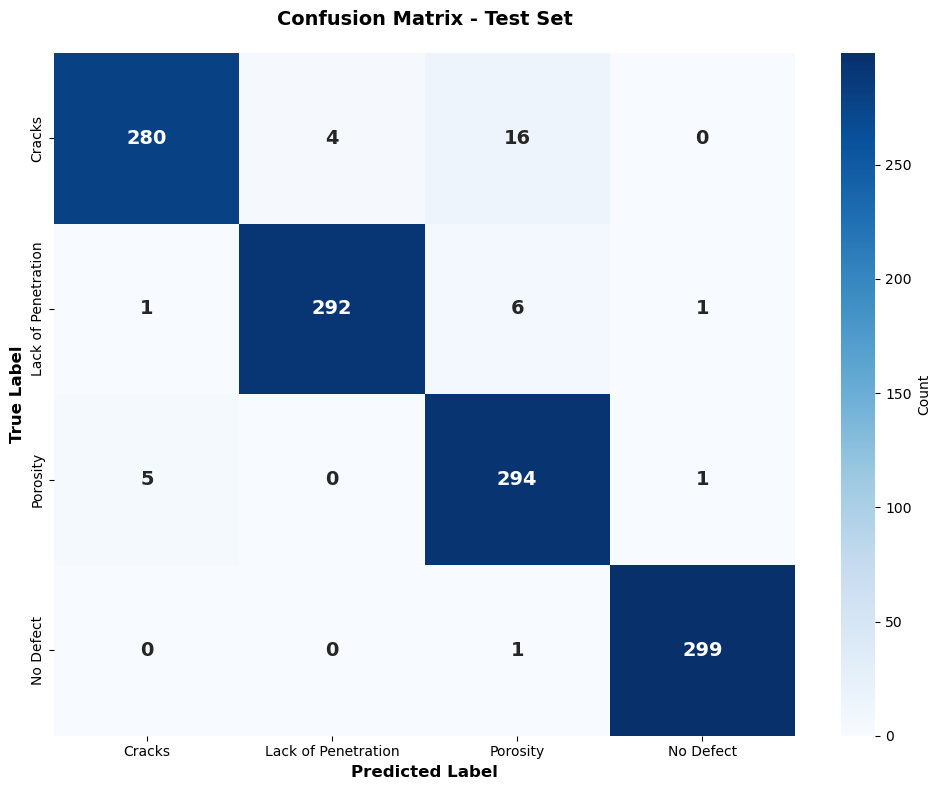

In [49]:
# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Part 18: Visualize Predictions

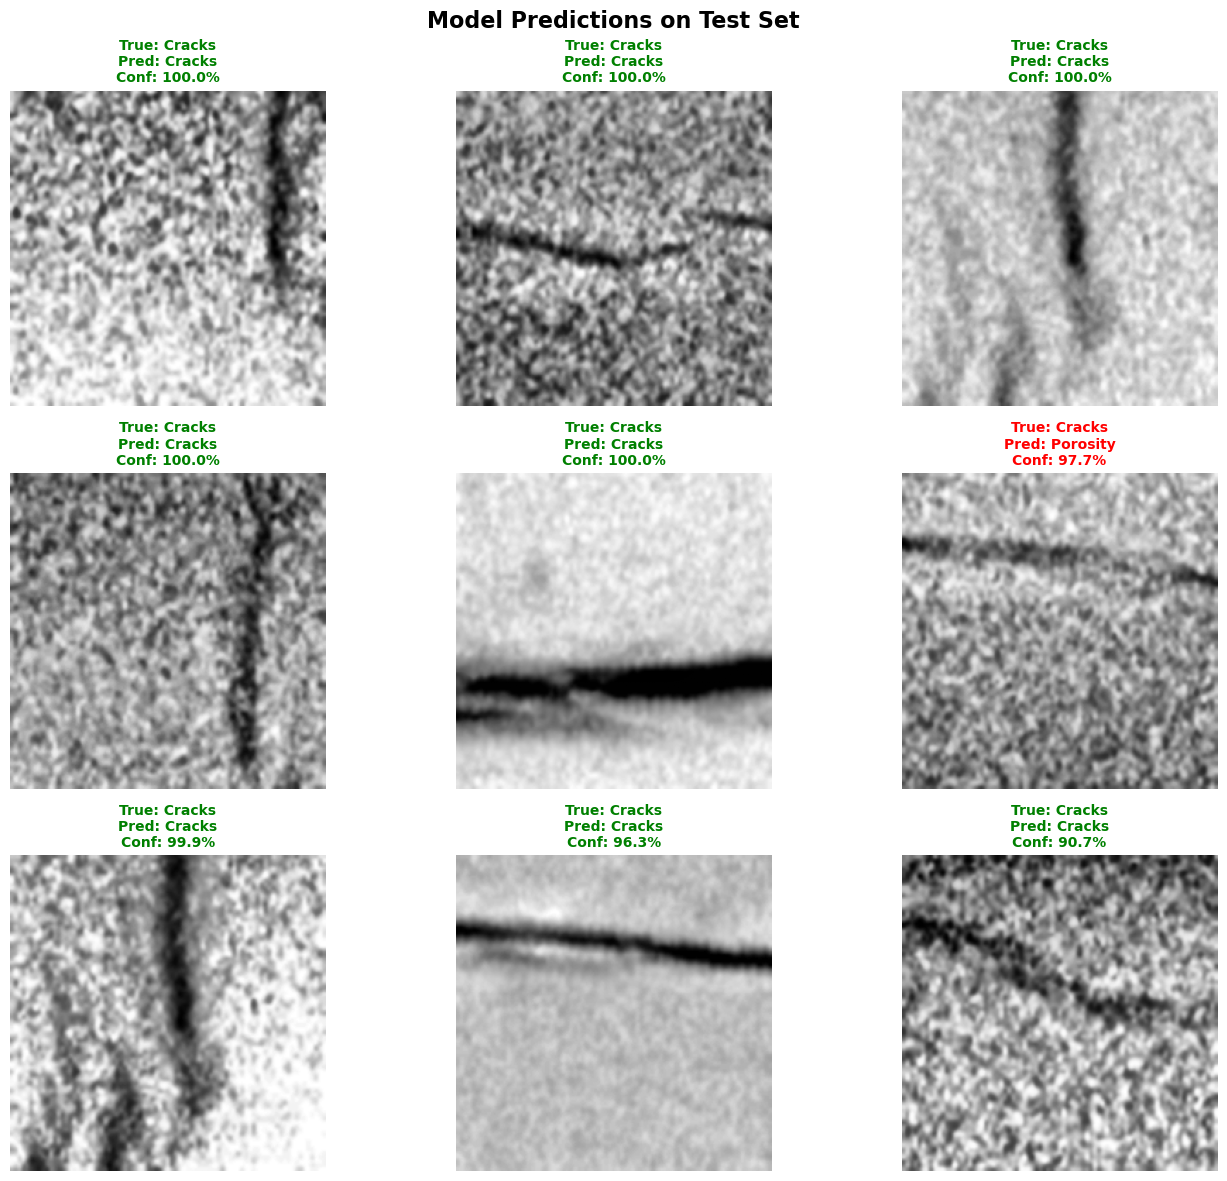

In [50]:
# Get predictions with probabilities
model.eval()
y_pred_probs_all = []
test_images = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        
        y_pred_probs_all.extend(probs.cpu().numpy())
        test_images.extend(images.cpu().numpy())
        test_labels.extend(labels.numpy())

# Visualize some predictions
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Model Predictions on Test Set', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    if idx < min(9, len(test_images)):
        img = test_images[idx]
        true_label_idx = test_labels[idx]
        pred_probs = y_pred_probs_all[idx]
        pred_label_idx = np.argmax(pred_probs)
        confidence = np.max(pred_probs) * 100
        
        true_label = CLASS_LABELS[CLASS_NAMES[true_label_idx]]
        pred_label = CLASS_LABELS[CLASS_NAMES[pred_label_idx]]
        
        # Color green if correct, red if incorrect
        color = 'green' if true_label_idx == pred_label_idx else 'red'
        
        # Denormalize and convert to display format
        img_display = (img * 0.5 + 0.5)
        img_display = np.transpose(img_display, (1, 2, 0))
        img_display = np.mean(img_display, axis=2)  # Grayscale
        
        ax.imshow(img_display, cmap='gray')
        title_text = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%'
        ax.set_title(title_text, color=color, fontweight='bold', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()


## Part 19: Save the Model

In [51]:
# Save model
saved_model_path = f"{FOLDER_PATH}riawelc_pytorch_model_{id}.pth"
saved_model_path_full = f"{FOLDER_PATH}riawelc_pytorch_model_full_{id}.pth"
torch.save(model.state_dict(), saved_model_path)
print(f"Model weights saved as '{saved_model_path}'")

# Save entire model
torch.save(model, saved_model_path_full)
print(f"Full model saved as '{saved_model_path_full}'")

# Save class mapping
import json
class_mapping = {
    'class_names': CLASS_NAMES,
    'class_labels': CLASS_LABELS
}
with open('class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)
print("Class mapping saved as 'class_mapping.json'")


Model weights saved as 'C:\\Users\\mp29984\\Desktop\\RIAWELC\\riawelc_pytorch_model_2025-10-30---18-17-00.pth'
Full model saved as 'C:\\Users\\mp29984\\Desktop\\RIAWELC\\riawelc_pytorch_model_full_2025-10-30---18-17-00.pth'
Class mapping saved as 'class_mapping.json'


## Part 20: Predict on New Images

In [ ]:
def predict_single_image(image_path, model, device, classes, labels):
    """
    Predict the class of a single radiographic weld image
    
    Args:
        image_path: Path to the PNG image
        model: Trained PyTorch model
        device: Device (cpu or cuda)
        classes: List of class names
        labels: Dictionary mapping class names to full labels
    
    Returns:
        Dictionary with prediction results
    """
    # Load and preprocess image (grayscale)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return {'error': f'Could not load image from {image_path}'}
    
    # Resize to CONFIG image_size
    img = cv2.resize(img, (CONFIG['image_size'], CONFIG['image_size']))
    
    # Apply CLAHE if enabled
    if CONFIG.get('use_clahe', False):
        clip = float(CONFIG.get('clahe_clip', 2.0))
        tile = int(CONFIG.get('clahe_tile', 8))
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(tile, tile))
        img = clahe.apply(img)
    
    # Convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    
    # Continue with existing transforms and prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        predicted_idx = torch.argmax(probs).item()
        confidence = probs[predicted_idx].item() * 100
    
    all_probs = {labels[classes[i]]: probs[i].item()*100 for i in range(len(classes))}
    
    return {
        'predicted_class': classes[predicted_idx],
        'predicted_label': labels[classes[predicted_idx]],
        'confidence': confidence,
        'all_probabilities': all_probs
    }

# Example: Test on one image from the test set
print("Testing prediction function on a test image...\n")
test_image_path = os.path.join(TESTING_PATH, CLASS_NAMES[1], 
                               os.listdir(os.path.join(TESTING_PATH, CLASS_NAMES[1]))[0])

result = predict_single_image(test_image_path, model, device, CLASS_NAMES, CLASS_LABELS)

print(f"Predicted Class: {result['predicted_class']}")
print(f"Label: {result['predicted_label']}")
print(f"Confidence: {result['confidence']:.2f}%")
print(f"\nAll Probabilities:")
for label, prob in result['all_probabilities'].items():
    print(f"  {label:30}: {prob:.2f}%")

Testing prediction function on a test image...

Predicted Class: LP
Label: Lack of Penetration
Confidence: 99.99%

All Probabilities:
  Cracks                        : 0.00%
  Lack of Penetration           : 99.99%
  Porosity                      : 0.01%
  No Defect                     : 0.00%
